# BUILD A OCR SCANNER
## This notebook outlines the concepts behind building an OCR Scanner for processing documents

### Steps
- Edge Detection
- Finding Contours
- Apply Perspective Transform

### 1. Edge Detection
- Load the image
- Resize the image
- Convert the image into grayscale
- Blur the image
- Apply canny detector
- Display the edges in the image

#### Import the libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

In [3]:
# Helper function to display images
def show_image(img, title='Image', cmap_type='gray'):
    plt.figure(figsize=(10, 6))
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

#### Load the image
https://raw.githubusercontent.com/subashgandyer/datasets/main/images/Receipt.png

In [5]:
image =cv2.imread("Receipt.png")

In [7]:
image = cv2.resize(image, (800, int(image.shape[0] * 800 / image.shape[1])))

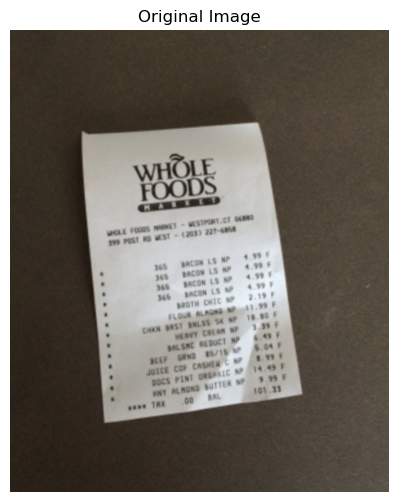

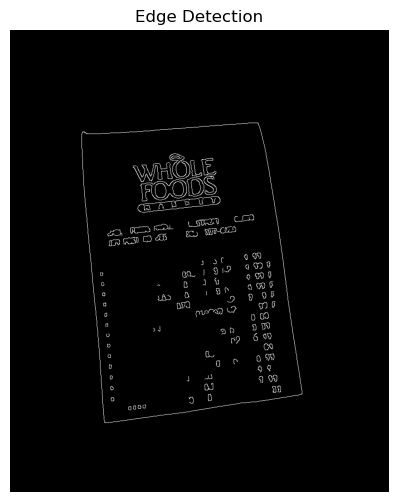

In [9]:
# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur the image
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny edge detector
edged = cv2.Canny(blurred, 75, 200)

# Display the original and edged image
show_image(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), title='Original Image', cmap_type=None)
show_image(edged, title='Edge Detection')

# 完整 OCR 掃描器程式碼 (使用 OpenCV)

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from skimage.filters import threshold_local

In [18]:
# ---------- Helper functions ----------
def show_image(img, title='Image', cmap_type='gray'):
    plt.figure(figsize=(10, 6))
    plt.imshow(img, cmap=cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

def resize_image(image, width):
    ratio = width / image.shape[1]
    dimension = (width, int(image.shape[0] * ratio))
    resized = cv2.resize(image, dimension, interpolation=cv2.INTER_AREA)
    return resized, ratio

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect

def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    return warped

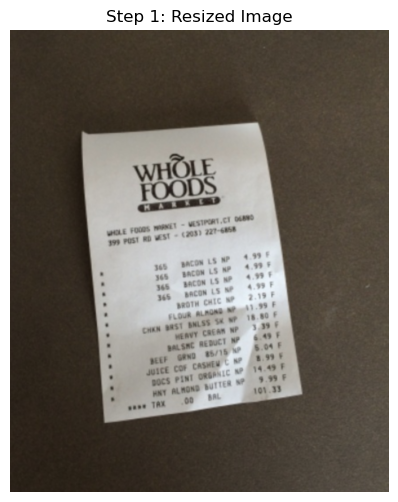

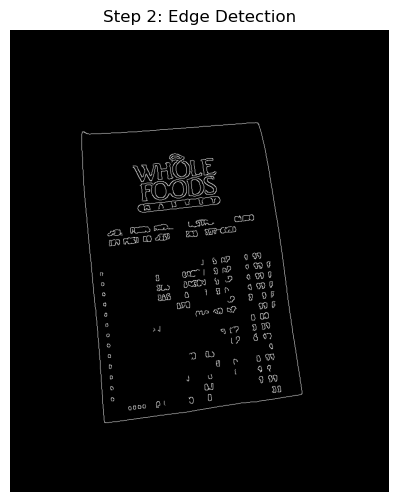

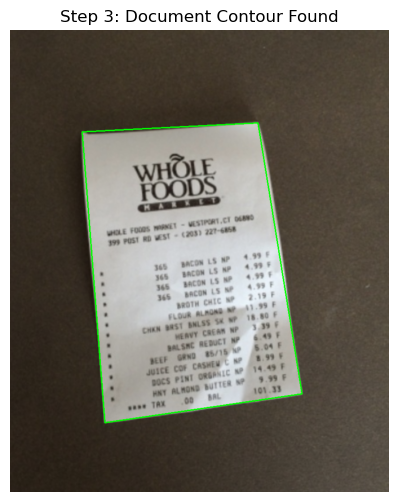

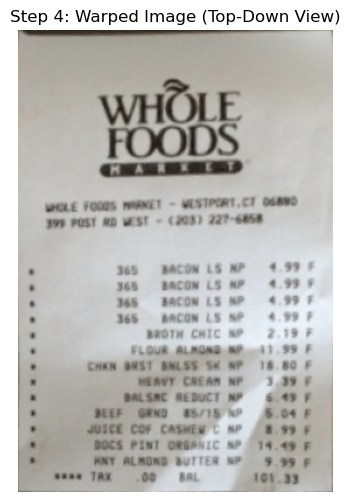

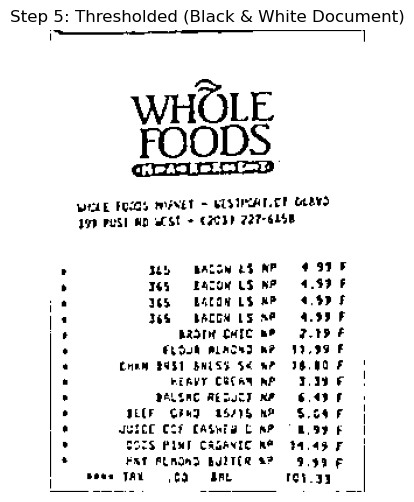

In [20]:
# ---------- Load Image ----------
url = 'https://raw.githubusercontent.com/subashgandyer/datasets/main/images/Receipt.png'
resp = urllib.request.urlopen(url)
image_np = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

orig = image.copy()
resized_image, ratio = resize_image(image, width=800)

show_image(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB), title="Step 1: Resized Image", cmap_type=None)

# ---------- Preprocess Image ----------
gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edged = cv2.Canny(blurred, 75, 200)

show_image(edged, title="Step 2: Edge Detection")

# ---------- Find Contours ----------
contours, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

for c in contours:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)

    if len(approx) == 4:
        screenCnt = approx
        break

# Draw contours
contour_img = resized_image.copy()
cv2.drawContours(contour_img, [screenCnt], -1, (0, 255, 0), 2)
show_image(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB), title="Step 3: Document Contour Found", cmap_type=None)

# ---------- Apply Perspective Transform ----------
warped = four_point_transform(orig, screenCnt.reshape(4, 2) * (orig.shape[1] / 800))

show_image(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB), title="Step 4: Warped Image (Top-Down View)", cmap_type=None)

# ---------- Grayscale and Threshold ----------
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
T = threshold_local(warped_gray, 11, offset=10, method="gaussian")
warped_thresh = (warped_gray > T).astype("uint8") * 255

show_image(warped_thresh, title="Step 5: Thresholded (Black & White Document)")

#### Resize the image
Helper function - resize with aspect ratio maintained

In [4]:
def resize(image, width=None, height=None, inter=cv2.INTER_AREA):
    # initialize the dimensions of the image to be resized and
    # grab the image size
    dim = None
    (h, w) = image.shape[:2]

    # if both the width and height are None, then return the
    # original image
    if width is None and height is None:
        return image

    # check to see if the width is None
    if width is None:
        # calculate the ratio of the height and construct the
        # dimensions
        r = height / float(h)
        dim = (int(w * r), height)

    # otherwise, the height is None
    else:
        # calculate the ratio of the width and construct the
        # dimensions
        r = width / float(w)
        dim = (width, int(h * r))

    # resize the image
    resized = cv2.resize(image, dim, interpolation=inter)

    # return the resized image
    return resized

In [5]:
ratio = image.shape[0] / 500.0
orig = image.copy()
image = resize(image, height = 500)

#### Convert the image into Grayscale

#### Blur the image

#### Canny Detector

#### Display the edges

## 2. Finding Contours
- FindContours()
- Sort the contours
- FInd the largest contour with 4 vertices
- Display the contour

#### Finding Contours

#### Sort the contours
Helper function - grab_contours()

In [13]:
def grab_contours(cnts): 
    if len(cnts) == 2: 
        cnts = cnts[0]
    elif len(cnts) == 3:
        cnts = cnts[1]
    else:
        raise Exception(("Contours tuple must have length 2 or "
                        "3, otherwise OpenCV changed their cv2.findContours " 
                        "return signature yet again. "
                        "Refer to OpenCV’s documentation in that case."))
    return cnts

#### Compute Perimeter and do Contour Approximation

In [17]:
peri = None
approx = None

#### Find the largest contour with 4 vertices

### Put it all together

#### Draw the contours

#### Display the contour

## 3. Perspective Transform
- Warp image using Four Point Transform
- Convert image into grayscale
- Threshold the image
- Display the image

#### Warp the image using Four Point Transform

### Helper function - 4 Point Transform

In [23]:
def four_point_transform(image, pts):
    # obtain a consistent order of the points and unpack them
    # individually
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # compute the width of the new image, which will be the
    # maximum distance between bottom-right and bottom-left
    # x-coordiates or the top-right and top-left x-coordinates
    widthA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
    widthB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
    maxWidth = max(int(widthA), int(widthB))

    # compute the height of the new image, which will be the
    # maximum distance between the top-right and bottom-right
    # y-coordinates or the top-left and bottom-left y-coordinates
    heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
    heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
    maxHeight = max(int(heightA), int(heightB))

    # now that we have the dimensions of the new image, construct
    # the set of destination points to obtain a "birds eye view",
    # (i.e. top-down view) of the image, again specifying points
    # in the top-left, top-right, bottom-right, and bottom-left
    # order
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]], dtype="float32")

    # compute the perspective transform matrix and then apply it
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    # return the warped image
    return warped

In [26]:
def order_points(pts):
    # initialzie a list of coordinates that will be ordered
    # such that the first entry in the list is the top-left,
    # the second entry is the top-right, the third is the
    # bottom-right, and the fourth is the bottom-left
    rect = np.zeros((4, 2), dtype = "float32")
    
    # the top-left point will have the smallest sum, whereas
    # the bottom-right point will have the largest sum
    s = pts.sum(axis = 1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    # now, compute the difference between the points, the
    # top-right point will have the smallest difference,
    # whereas the bottom-left will have the largest difference
    diff = np.diff(pts, axis = 1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    return rect


In [27]:
warped = None

#### Convert the warped image into grayscale

In [28]:
warped = None

#### Threshold the image

In [30]:
# T = threshold_local(warped, 11, offset = 10, method = "gaussian")
warped = None

#### Display the image

### Try different images